# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 2: Introdução à Realimentação

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professor:** Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** V <br>
**Aluno(a):** Mariana Leister Gonçalves, **RA:** 233115 <br>
**Aluno(a):** , **RA:** ?????? <br>
**Aluno(a):** , **RA:** ?????? <br>

## Bibliotecas

In [1]:
%pip install control numpy pandas plotly matplotlib nbformat

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import control as ctrl
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## (1) Controle em malha aberta × controle proporcional ao erro

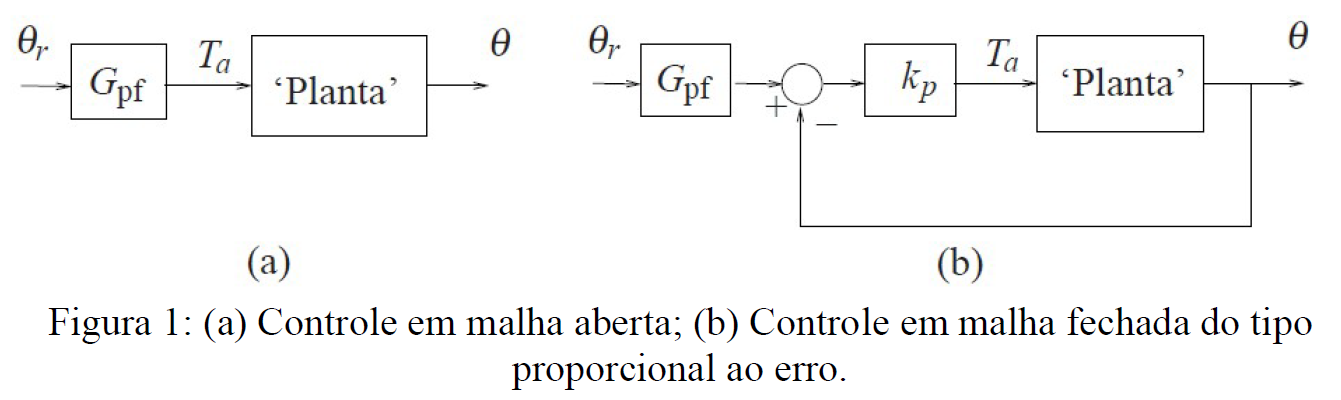

##### (a) Função de transferência de malha aberta

Funções de transferência:
Planta: $G(s) = \frac{1}{s^2 + 2s + 5}$
    
Malha aberta: $G_{MA} = \frac{G_{pf}}{s^2 + 2s + 5}$
    
Malha fechada: $G_{MF} = \frac{G_{pf}k_p}{s^2 + 2s + 5 + k_p}$

Na configuração em malha aberta, o sistema é composto por um ganho de pré-filtro $G_{pf}$ em série com a planta $G(s) = \frac{1}{s^2 + 2s + 5}$.
Como não há realimentação, a função de transferência do sistema em malha aberta é dada pelo produto entre o pré-filtro e a planta, isto é, $G_{MA}(s) = G_{pf}\,G(s) = \frac{G_{pf}}{s^2 + 2s + 5}$.

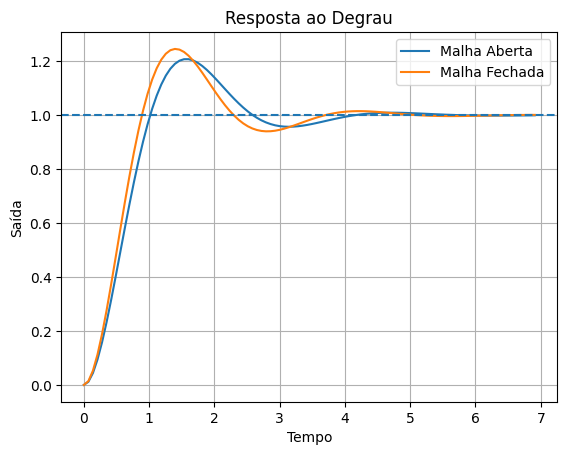

In [3]:
# Item A - Plot das funções de transferência

s = ctrl.TransferFunction.s
G = 1 / (s**2 + 2*s + 5) # Função de transferência da planta

# Malha aberta
Gpf_open = 1            # Valor inicial do ganho
G_MA = Gpf_open * G     # Função de tranferência em malha aberta

# Malha fechada
kp = 1  # Ganho do controlador
G_closed_loop = ctrl.feedback(kp * G, 1) # Malha fechada com realimentação unitária
# G_MF = (kp*G) / (1 + kp*G)


# Pré-Filtro
# Como desejamos erro nulo ao degrau, o ganho DC total deve ser 1

# Em malha aberta
dc_gain_open = ctrl.dcgain(G)
Gpf_open = 1 / dc_gain_open     # G_pf = 1 / G(0)

# GANHO DE MALHA ABERTA
G_MA = Gpf_open * G     # Atualiza malha aberta com o valor correto

# Em malha fechada
dc_gain_closed = ctrl.dcgain(G_closed_loop)
Gpf_closed = 1 / dc_gain_closed

# GANHO DE MALHA FECHADA
G_MF = Gpf_closed * G_closed_loop

# Resposta ao degrau (domínio do tempo)
t1, y1 = ctrl.step_response(G_MA)
t2, y2 = ctrl.step_response(G_MF)

#############

plt.plot(t1, y1, label="Malha Aberta")
plt.plot(t2, y2, label="Malha Fechada")
plt.axhline(1, linestyle='--')  # referência do degrau
plt.xlabel("Tempo")
plt.ylabel("Saída")
plt.title("Resposta ao Degrau")
plt.legend()
plt.grid()
plt.show()


# Item B
Para resolver esse item, devemos garantir que o erro em regime estacionário seja nulo para uma entrada degrau. 

O erro é definido como $E(s)=\theta_r(s)-\theta(s)$ e o erro de regime é dado como $e_{ss}=lim_{s\to 0}sE(s)$.

A entrada de um degrau unitário é definido como $\theta_r(s)=\frac{1}{s}$. A saída do sistema pode ser reescrito como $\theta(s)=T(s)\cdot \theta_r(s)$. Substituindo esses valores, temos
$E(s)=\theta_r(s)-T(s)\theta_r(s)=\theta_r(s)[1-T(s)]$ ou $E(s)=\frac{1}{s}[1-T(s)]$

Agora, podemos aplicar o erro de regime. A equação fica
$e_{ss}=lim_{s\to 0}sE(s) \to e_{ss}=lim_{s\to 0}s\cdot {\frac{1}{s}[1-T(s)]} \to e_{ss}= 1\cdot [1-T(0)]$

Para que o erro seja nulo, precisamos que
$e_{ss}=1-T(0)=0 \to T(0)=1$

Ou seja, temos que o ganho DC da função de transferência em cada caso deve ser igual a 1. Agora vamos aplicar esse resultado para dois tipos de malha

## Malha aberta
A função de transferência de malha aberta é 

$G_{MA}(s)=\frac{\theta(s)}{\theta_r(s)}=G_{pf}\cdot G(s)=\frac{G_{pf}}{s^2+2s+5}$

Como temos a condição de que $G_{MA}(0)=1$, temos que 
$G_{MA}(0)=\frac{G_{pf}}{0^2+2\cdot 0+5} = \frac{G_{pf}}{5}$

Também sabemos que essa condição precisa resultar em 1, portanto temos 
$G_{MA}=\frac{G_{pf}}{5}=1 \to G_{pf}=5$

## Malha fechada
Temos que a função de transferência da malha fechada é
$G_{MF}=\frac{G_{pf}\cdot k_p}{s^2+2s+5+k_p}$

Aplicando a condição de que $G(0)=1$, temos que 
$G_{MF}=\frac{G_{pf}\cdot k_p}{0^2+2\cdot 0+5+k_p}=1$

$G_{MF}=\frac{G_{pf}\cdot kp}{5+k_p}=1 \to G_{pf}=\frac{k_p+5}{k_p}$

Portanto, temos que $G_{pf}=1+\frac{5}{k_p}$

In [4]:
# @title Gráficos (c)

# =========================
# Parâmetros
# =========================

deltas = np.arange(1, 4.5, 0.5)
t = np.linspace(0, 10, 1000)

# =========================
# (c) MALHA ABERTA
# =========================

Gpf_open = 5  # obtido no item (b)

fig_open = go.Figure()
erro_open = []

for Delta in deltas:
    # Planta perturbada
    num = [1]
    den = [1, 2, 5 - Delta]
    Gpert = ctrl.TransferFunction(num, den)

    # Sistema em malha aberta
    G_open = Gpf_open * Gpert

    # Resposta ao degrau
    t_out, y = ctrl.step_response(G_open, t)

    fig_open.add_trace(go.Scatter(
        x=t_out,
        y=y,
        mode='lines',
        name=f'Δ = {Delta}'
    ))

    # Erro de regime permanente analítico
    ess = -Delta / (5 - Delta)
    erro_open.append(ess)

fig_open.update_layout(
    title=dict(text='Resposta ao Degrau <br> Malha Aberta',
               x=0.5),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída θ(t)',
    width=600,
    height=400,
)

fig_open.show()

# =========================
# Erro vs. Delta - Malha Aberta
# =========================

fig_erro_open = go.Figure()

fig_erro_open.add_trace(go.Scatter(
    x=deltas,
    y=erro_open,
    mode='lines+markers'
))

fig_erro_open.update_layout(
    title=dict(text='Erro de Regime vs. Δ <br> Malha Aberta',
               x=0.5),
    xaxis_title='Δ',
    yaxis_title='Erro de Regime',
    width=600,
    height=400,
)

fig_erro_open.show()

##### Item D

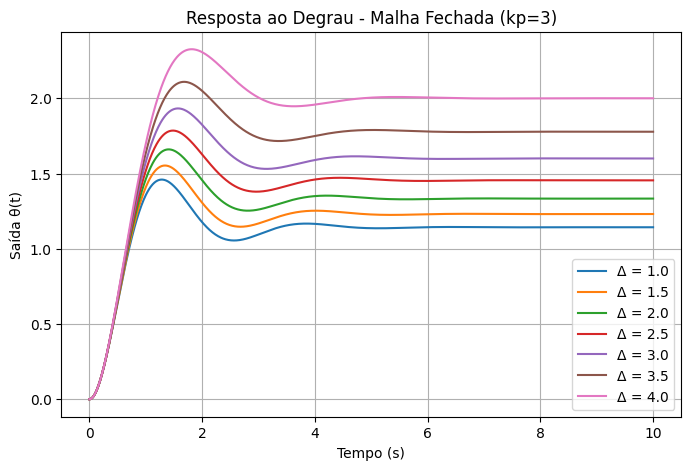

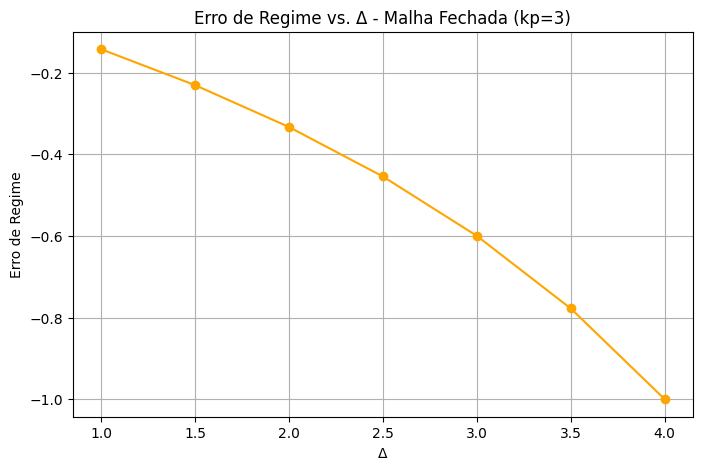

In [7]:
# =========================
# Parâmetros Iniciais
# =========================
deltas = np.arange(1, 4.5, 0.5)
t = np.linspace(0, 10, 1000)

# =========================
# (d) MALHA FECHADA (kp = 3)
# =========================
kp = 3
Gpf_closed = (kp + 5) / kp  # Resulta em 8/3

# Preparando as listas e a figura da resposta ao degrau
erro_closed = []
plt.figure(figsize=(8, 5))

for Delta in deltas:
    # Planta perturbada
    num = [1]
    den = [1, 2, 5 - Delta]
    Gpert = ctrl.TransferFunction(num, den)

    # Sistema em malha fechada
    G_loop = ctrl.feedback(kp * Gpert, 1)
    G_closed = Gpf_closed * G_loop

    # Resposta ao degrau
    t_out, y = ctrl.step_response(G_closed, t)

    # Plotando cada linha no mesmo gráfico
    plt.plot(t_out, y, label=f'Δ = {Delta}')

    # Calculando e guardando o erro de regime
    ess = -Delta / (8 - Delta)
    erro_closed.append(ess)

# Configurações visuais do gráfico de Resposta ao Degrau
plt.title('Resposta ao Degrau - Malha Fechada (kp=3)')
plt.xlabel('Tempo (s)')
plt.ylabel('Saída θ(t)')
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Gráfico do Erro vs. Delta
# =========================
plt.figure(figsize=(8, 5))
plt.plot(deltas, erro_closed, marker='o', color='orange', linestyle='-')

# Configurações visuais do gráfico de Erro
plt.title('Erro de Regime vs. Δ - Malha Fechada (kp=3)')
plt.xlabel('Δ')
plt.ylabel('Erro de Regime')
plt.grid(True)
plt.show()

In [5]:
# @title Gráficos (e)

# =========================
# Parâmetros
# =========================

kp_values = np.arange(3, 18, 3)  # 3,6,9,12,15
t = np.linspace(0, 10, 1000)

# =========================
# Resposta ao Degrau - Δ = 0
# =========================

fig_nominal = go.Figure()
erro_nominal = []

for kp in kp_values:

    Delta = 0

    # Pré-filtro calculado com planta nominal
    Gpf = (5 + kp) / kp

    # Planta
    num = [1]
    den = [1, 2, 5 - Delta]
    G = ctrl.TransferFunction(num, den)

    # Malha fechada
    G_forward = kp * G
    G_closed = ctrl.feedback(G_forward, 1)

    # Aplicando pré-filtro
    G_total = Gpf * G_closed

    # Resposta ao degrau
    t_out, y = ctrl.step_response(G_total, t)

    fig_nominal.add_trace(go.Scatter(
        x=t_out,
        y=y,
        mode='lines',
        name=f'kp = {kp}'
    ))

    # Erro analítico
    ess = -Delta / (kp + 5 - Delta)
    erro_nominal.append(ess)

fig_nominal.update_layout(
    title=dict(text='Resposta ao Degrau <br> Δ = 0 (Planta Nominal)',
               x=0.5),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída θ(t)',
    width=600,
    height=400,
)

fig_nominal.show()


# =========================
# Resposta ao Degrau - Δ = 2
# =========================

fig_pert = go.Figure()
erro_pert = []

for kp in kp_values:
    Delta = 2

    # Pré-filtro continua usando planta nominal
    # Não é alterado com Δ
    Gpf = (5 + kp) / kp

    # Planta perturbada
    num = [1]
    den = [1, 2, 5 - Delta]
    G = ctrl.TransferFunction(num, den)

    # Malha fechada
    G_forward = kp * G
    G_closed = ctrl.feedback(G_forward, 1)

    # Sistema total
    G_total = Gpf * G_closed

    # Resposta ao degrau
    t_out, y = ctrl.step_response(G_total, t)

    fig_pert.add_trace(go.Scatter(
        x=t_out,
        y=y,
        mode='lines',
        name=f'kp = {kp}'
    ))

    # Erro de regime
    ess = -Delta / (kp + 5 - Delta)
    erro_pert.append(ess)

fig_pert.update_layout(
    title=dict(text='Resposta ao Degrau <br> Δ = 2 (Planta Perturbada)', x=0.5),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída θ(t)',
    width=600,
    height=400,
)
fig_pert.show()


# =========================
# Erro vs. kp
# =========================

fig_erro = go.Figure()

fig_erro.add_trace(go.Scatter(
    x=kp_values,
    y=erro_nominal,
    mode='lines+markers',
    name='Δ = 0'
))

fig_erro.add_trace(go.Scatter(
    x=kp_values,
    y=erro_pert,
    mode='lines+markers',
    name='Δ = 2'
))

fig_erro.update_layout(
    title=dict(text='Erro de Regime vs. kp',
               x=0.5),
    xaxis_title='kp',
    yaxis_title='Erro de Regime',
    width=600,
    height=400,
)

fig_erro.show()

##### Item F

Sistemas em malha aberta possuem como principal vantagem a facilidade de implementação, devido ao fato de não utilizarem realimentação. Isso reduz o custo computacional e evita problemas de instabilidade associados ao fechamento de malha. Além disso, são adequados quando o modelo do sistema é bem conhecido e as condições de operação não variam significativamente. No entanto, uma de suas desvantagens é a ausência de correção de erros, ou seja, por reagir a perturbações externas nem incertezas no modelo, o sistema poode estar associado a erros de regime permanente e baixa precisão.

Por outro lado, sistemas em malha fechada utilizam realimentação para comparar a saída com a referência, permitindo corrigir o erro ao longo do tempo. Por este motivo, apresentam maior robustez a perturbações e variações no modelo, além de apresentarem melhor desempenho em termos de precisão e rejeição de distúrbios, mesmo com controle proporcional. Essa estrutura, contudo, sendo mais complexa, pode sofrer problemas de estabilidade se os parâmetros associados não forem adequadamente ajustados, e a presença de realimentação pode amplificar ruídos na medição.

## (2) Controladores PID: regras de Ziegler–Nichols

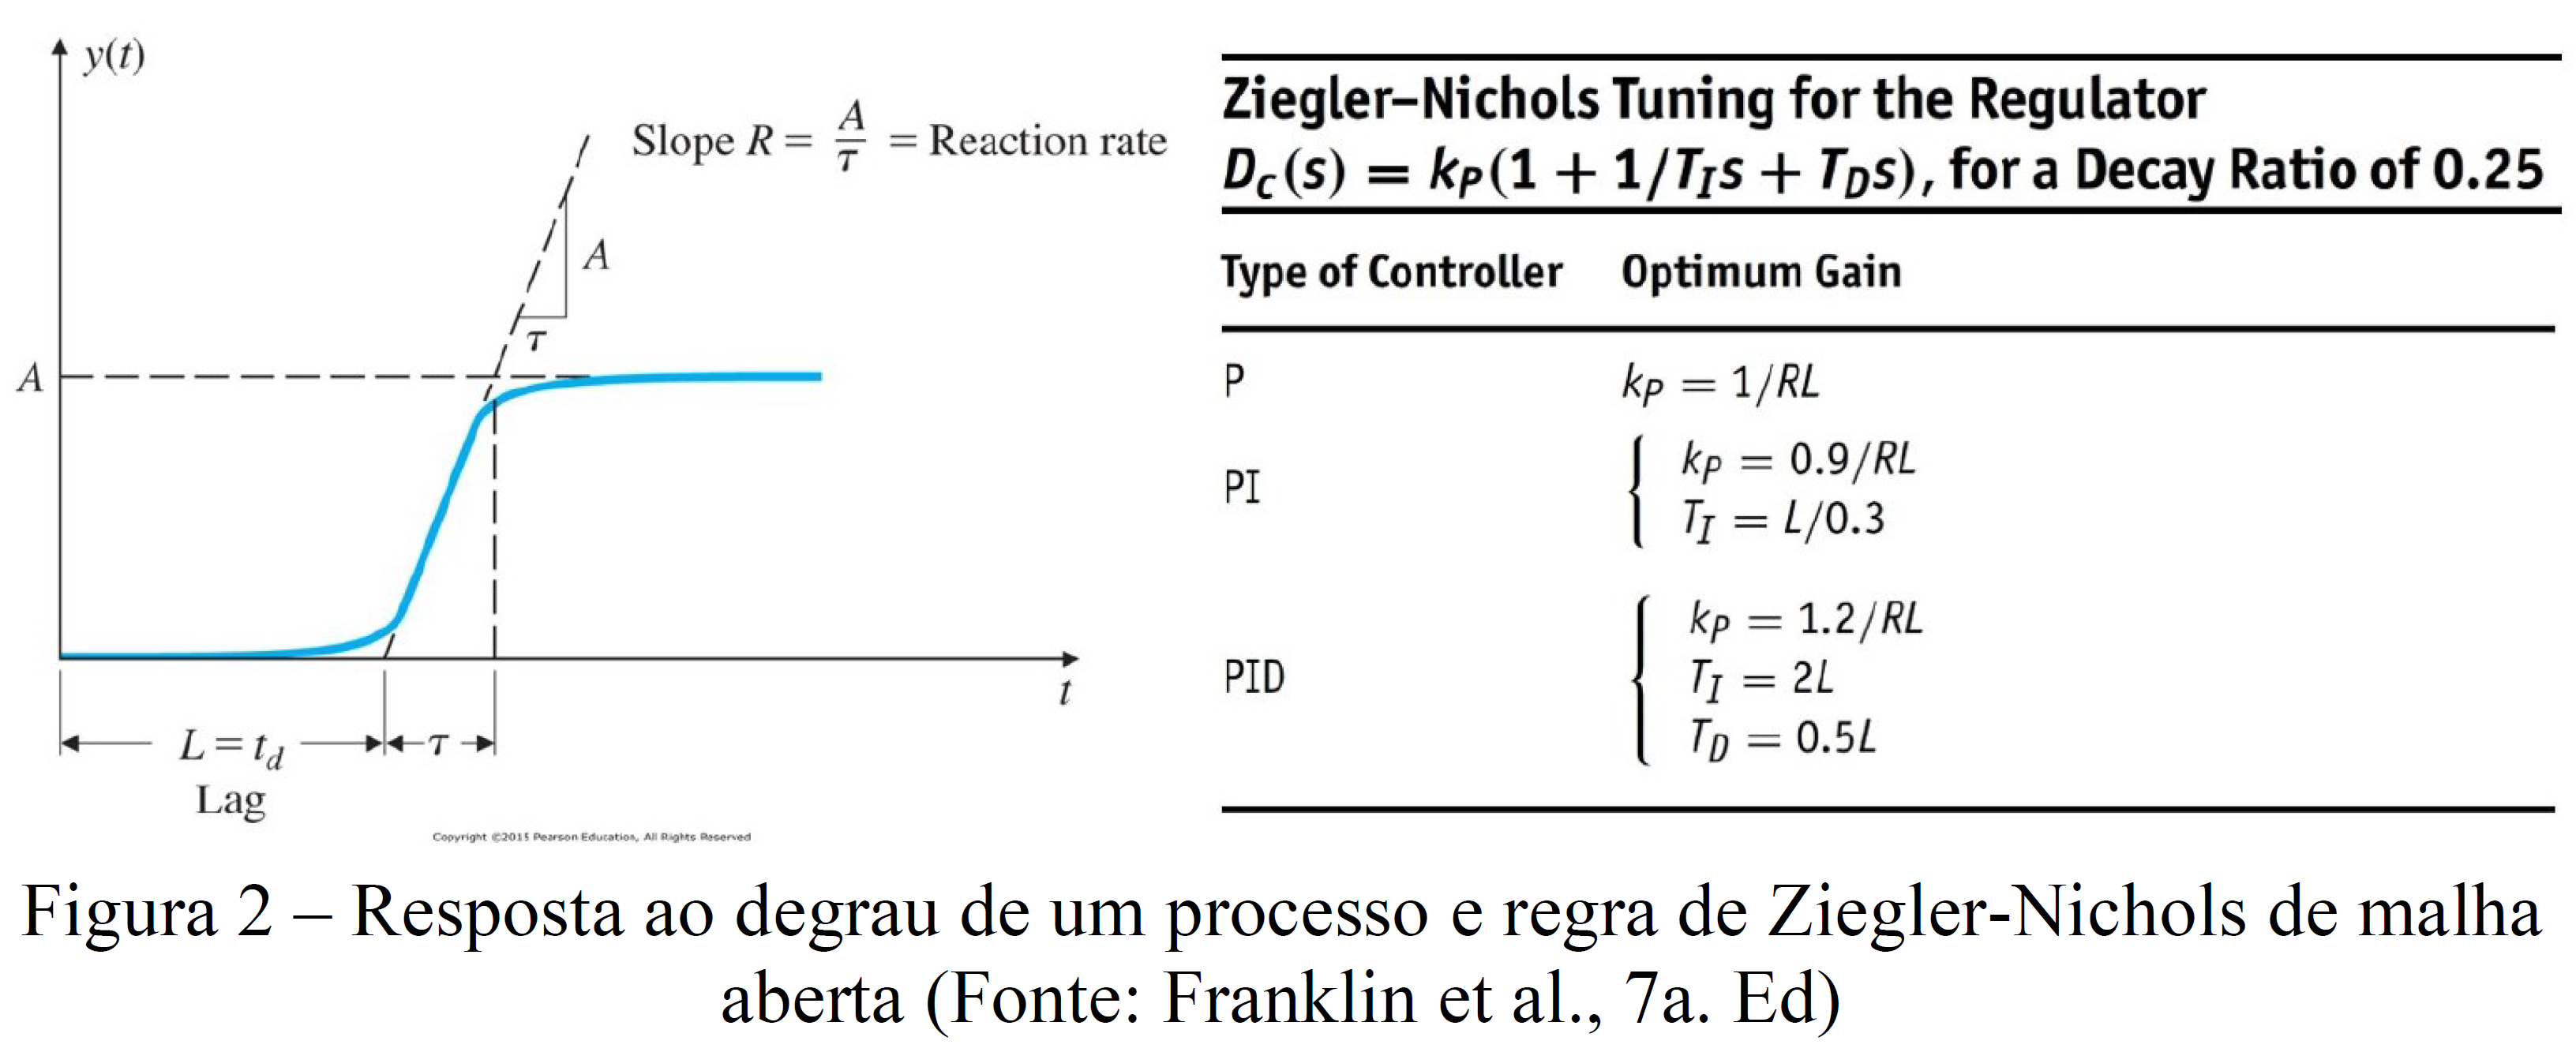

In [8]:
#LETRA A

"Usando os valores de L = t1 e 𝜏 = t2 - t1, aplique a regra de Ziegler-Nichols de malha aberta da Figura 2, apresentando"
"todos os cálculos pertinentes para obter os controladores P, PI e PID. Plote a resposta ao degrau de todos eles num"
"mesmo gráfico."

#RESPOSTA LETRA A

"Segundo valores dados pelo gráfico, temos que t1 = 0.76 e t2 = 2.72. Sabemos que L = t1 = 0.76 e 𝜏 = t2 - t1 = 1.96."
"Além disso, também é possível estimar o valor de A, que é o valor final da resposta ao degrau. Dado que a entrada é um"
"degrau unitário e a planta é estável, o valor final da saída é o ganho DC da planta, ou seja: A = G(0). Sendo assim, a"
"função de transferência que é dada por: G = 10 / (s+1)(s+2)(s+3)(s+4), pode ser reescrita como: "
"A = G(0) = 10 / (1 * 2 * 3 * 4) = 0,41666. Por fim, a taxa de reação R pode ser calculada através da relação = A/𝜏."
"Logo, R = 0,41666 / 1.96 = 0.2126. Com estes dados em mãos, podemos calcular as constantes utilizando as fórmulas dadas"
"na figura 2:"
"P:    kp = 1 / (RL) = 1 / (0.2126 * 0.76) = 6.1895"
"PI:   kp = 0.9 / (RL) = 0.9 / (0.2126 * 0.76) = 5.57"
"      TI = L / 0.3 = 0.76 / 0.3 = 2.53"
"PID:  kp = 1.2 / (RL) = 1.2 / (0.2126 * 0.76) = 7.4268"
"      TI = 2 * L = 2 * 0.76 = 1.52"
"      TD = 0.5 * L = 0.5 * 0.76 = 0.38"


# @title Gráfico (a)

# =========================
# Tempo de simulação
# =========================

t = np.linspace(0, 20, 1000)

# =========================
# Planta
# =========================

num = [10]
den = np.polymul([1,1], np.polymul([1,2], np.polymul([1,3],[1,4])))
G = ctrl.TransferFunction(num, den)

# =========================
# Parâmetros Ziegler-Nichols
# =========================

L = 0.76
tau = 2.72 - 0.76
A = 10 / (1*2*3*4)
R = A / tau

Kp_P = 1 / (R*L)

Kp_PI = 0.9 / (R*L)
Ti_PI = L / 0.3

Kp_PID = 1.2 / (R*L)
Ti_PID = 2 * L
Td_PID = 0.5 * L

# =========================
# Controladores
# =========================

Cp = Kp_P

Cpi = Kp_PI * ctrl.TransferFunction([Ti_PI,1],[Ti_PI,0])

Cpid = Kp_PID * ctrl.TransferFunction(
    [Ti_PID*Td_PID, Ti_PID, 1],
    [Ti_PID, 0]
)

# =========================
# Sistemas em malha fechada
# =========================

Tp = ctrl.feedback(Cp*G,1)
Tpi = ctrl.feedback(Cpi*G,1)
Tpid = ctrl.feedback(Cpid*G,1)

# =========================
# Respostas ao degrau
# =========================

t_p, y_p = ctrl.step_response(Tp, t)
t_pi, y_pi = ctrl.step_response(Tpi, t)
t_pid, y_pid = ctrl.step_response(Tpid, t)

# =========================
# Plot
# =========================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=t_p,
    y=y_p,
    mode='lines',
    name='P'
))

fig.add_trace(go.Scatter(
    x=t_pi,
    y=y_pi,
    mode='lines',
    name='PI'
))

fig.add_trace(go.Scatter(
    x=t_pid,
    y=y_pid,
    mode='lines',
    name='PID'
))

fig.update_layout(
    title=dict(
        text='Resposta ao Degrau <br> Controladores Ziegler-Nichols (Malha Aberta)',
        x=0.5
    ),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída y(t)',
    width=700,
    height=450,
)

fig.show()

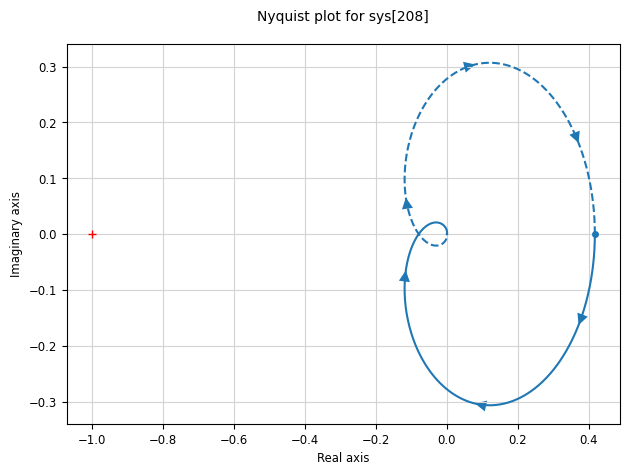

12.600000000000003
2.8099258924162904


In [9]:
# LETRA B

"Para a mesma planta do item 2a, aplique a regra de Ziegler-Nichols de malha fechada da Figura 3, apresentando todos os"
"cálculos pertinentes para obter os controladores P, PI e PID. Plote a resposta ao degrau de todos eles num mesmo"
"gráfico"

#RESPOSTA LETRA B

"Nesta questão, o ganho último Ku é o ganho proporcional no limiar de instabilidade, e Pu é o período da oscilação nesse"
"ponto. Isso será feito para a mesma planta do item A. O código de suporte fornecido alcula esses valores usando a"
"função ctrl.margin(G). Na figura 3 foram fornecidas as novas relações a serem calculadas:"
"P:    kp = 0.5 * Ku"
"PI:   kp = 0.45 * Ku"
"      TI = Pu / 1.2"
"PID:  kp = 0.6 * Ku"
"      TI = 0.5 * Pu"
"      TD = 0.125 * Pu"



# @title Gráfico de suporte (b)

# Planta

num = [10]
den = np.polymul([1,1], np.polymul([1,2], np.polymul([1,3],[1,4])))
G = ctrl.TransferFunction(num, den)

# Tempo de simulação

ctrl.nyquist_plot(G)
plt.show()

Ku, pm, wg, wp = ctrl.margin(G)

Pu = 2 * np.pi / wg

print(Ku)
print(Pu)

# Controlador P
Kp_P = 0.5 * Ku

# Controlador PI
Kp_PI = 0.45 * Ku
Ti_PI = Pu / 1.2

# Controlador PID
Kp_PID = 0.6 * Ku
Ti_PID = 0.5 * Pu
Td_PID = 0.125 * Pu

# Criando as funções de transferência dos controladores
Cp = Kp_P
Cpi = Kp_PI * ctrl.TransferFunction([Ti_PI, 1], [Ti_PI, 0])
Cpid = Kp_PID * ctrl.TransferFunction(
    [Ti_PID * Td_PID, Ti_PID, 1], 
    [Ti_PID, 0]
)

# Malhas fechadas
Tp = ctrl.feedback(Cp * G, 1)
Tpi = ctrl.feedback(Cpi * G, 1)
Tpid = ctrl.feedback(Cpid * G, 1)

# Respostas ao degrau (usando o mesmo vetor de tempo 't' do item A)
t_p, y_p = ctrl.step_response(Tp, t)
t_pi, y_pi = ctrl.step_response(Tpi, t)
t_pid, y_pid = ctrl.step_response(Tpid, t)